In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow import keras
from copy import copy, deepcopy
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical

In [2]:
# Replace __FILL_ME__ with your information

# Data preparation and prepcrossing

In [3]:
# load data
(data_train, label_train), (data_test, label_test) = mnist.load_data()

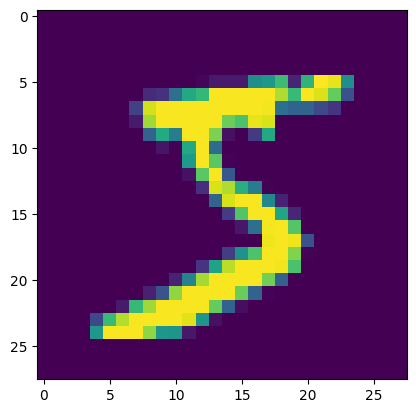

In [4]:
# display one test figure
test_fig = data_train[0]
plt.imshow(test_fig)

In [5]:
# normalize the data into the range of 0-1
data_train = data_train/data_train.max()
data_test = data_test/data_test.max()

Label = 0


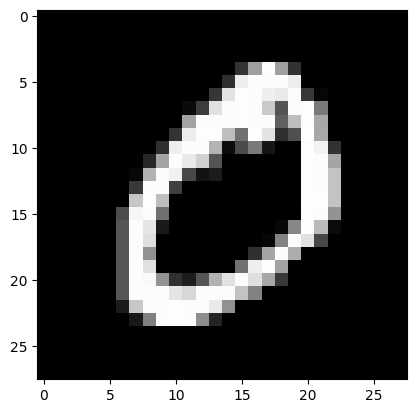

Label = 1


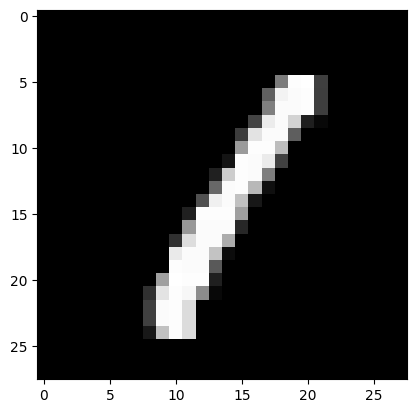

Label = 2


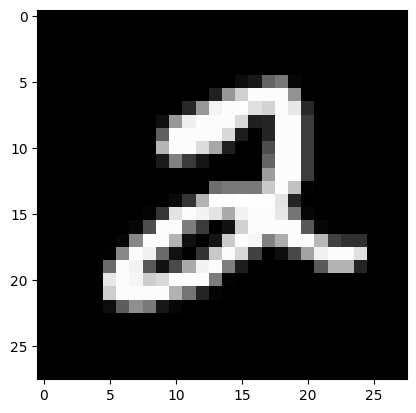

Label = 3


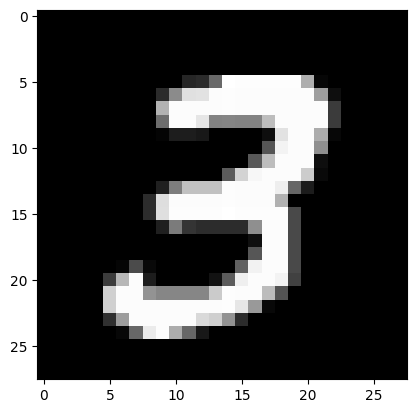

Label = 4


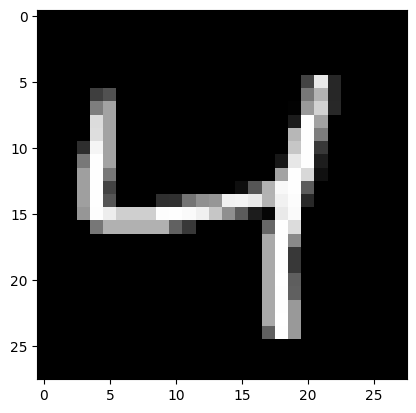

Label = 5


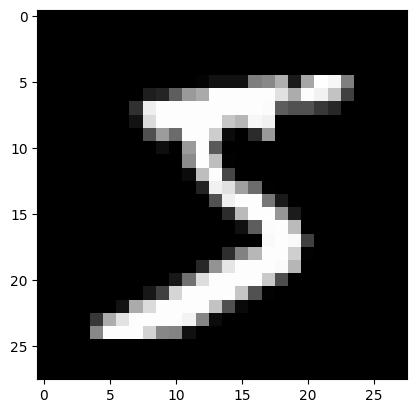

Label = 6


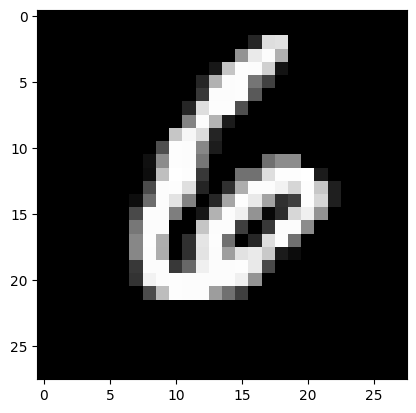

Label = 7


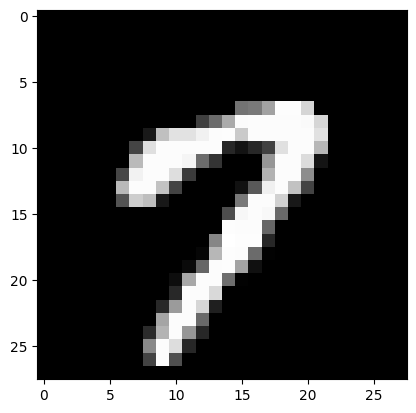

Label = 8


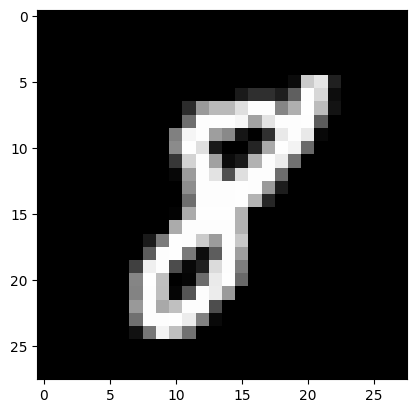

Label = 9


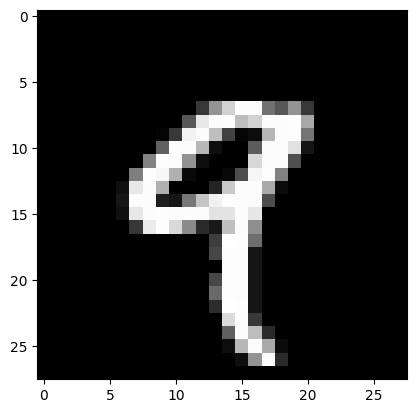

In [6]:
# display fig for each class
for i in range(10):
    for img_idx in range(10000):
        if int(label_train[img_idx]) == i:
            print('Label =', i)
            plt.imshow(data_train[img_idx], cmap = 'gray')
            plt.show()
            break
    

In [7]:
# 32 Floating Point data type is used
import sys
mem_fig = sys.getsizeof(data_train[0])
print('The required memory useage for each figure is: {}Byte'.format(mem_fig) )

The required memory useage for each figure is: 128Byte


# Construct the MLP

In [8]:
# Considerations: number of layers, number of neurons in each layer, activation function

In [9]:
# Build up the MLP
# later you can change the number of neurons and layers

input_layer = Input(shape=data_train[0].shape)
input_layer_f = Flatten()(input_layer)

hidden_layer_1     = Dense(5, name='dense_1')(input_layer_f)
hidden_layer_1_act = Activation("relu", name="act_1")(hidden_layer_1)

hidden_layer_2     = Dense(8, name='dense_2')(hidden_layer_1_act)
hidden_layer_2_act = Activation("relu", name="act_2")(hidden_layer_2)

hidden_layer_3     = Dense(8, name='dense_3')(hidden_layer_2_act)
hidden_layer_3_act = Activation("relu", name="act_3")(hidden_layer_3)

output_layer       = Dense(10, name='output_layer')(hidden_layer_3_act)
output_layer_act   = Activation("softmax", name="softmax")(output_layer)

model = Model(input_layer, output_layer_act)

In [10]:
parameter_by_layer = np.zeros([4])

# layer 1
parameter_by_layer[0] = sys.getsizeof(model.layers[2].get_weights()[:2])
# layer 2
parameter_by_layer[1] = sys.getsizeof(model.layers[4].get_weights()[:2])
# layer 3 
parameter_by_layer[2] = sys.getsizeof(model.layers[6].get_weights()[:2])
# layer 4
parameter_by_layer[3] = sys.getsizeof(model.layers[8].get_weights()[:2])

mem_model = parameter_by_layer.sum()
            
print('The total memory usage for weights and bias is {}Byte'.format(mem_model))

The total memory usage for weights and bias is 288.0Byte


In [11]:
# check the parameter numbers
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense_1 (Dense)             (None, 5)                 3925      
                                                                 
 act_1 (Activation)          (None, 5)                 0         
                                                                 
 dense_2 (Dense)             (None, 8)                 48        
                                                                 
 act_2 (Activation)          (None, 8)                 0         
                                                                 
 dense_3 (Dense)             (None, 8)                 72    

# Model Training

In [12]:
# compile model
# define optimizer to perform backpropagation, loss function to evaluate loss
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
# train model with 80% data for training and 20% for validation with specified number of epochs, a small number is reconmmand (10)
r = model.fit(data_train, label_train, validation_split= 0.2, epochs=10)

Epoch 1/10


1500/1500 [==============================] - 16s 8ms/step - loss: 0.9843 - accuracy: 0.6643 - val_loss: 0.5838 - val_accuracy: 0.8155
Epoch 2/10
1500/1500 [==============================] - 12s 8ms/step - loss: 0.5466 - accuracy: 0.8292 - val_loss: 0.4868 - val_accuracy: 0.8529
Epoch 3/10
1500/1500 [==============================] - 11s 8ms/step - loss: 0.4760 - accuracy: 0.8579 - val_loss: 0.4308 - val_accuracy: 0.8727
Epoch 4/10
1500/1500 [==============================] - 12s 8ms/step - loss: 0.4416 - accuracy: 0.8702 - val_loss: 0.4173 - val_accuracy: 0.8780
Epoch 5/10
1500/1500 [==============================] - 11s 7ms/step - loss: 0.4214 - accuracy: 0.8766 - val_loss: 0.4012 - val_accuracy: 0.8808
Epoch 6/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.4094 - accuracy: 0.8800 - val_loss: 0.4023 - val_accuracy: 0.8790
Epoch 7/10
1500/1500 [==============================] - 4s 2ms/step - loss: 0.3964 - accuracy: 0.8840 - val_loss: 0.3777 - val_ac

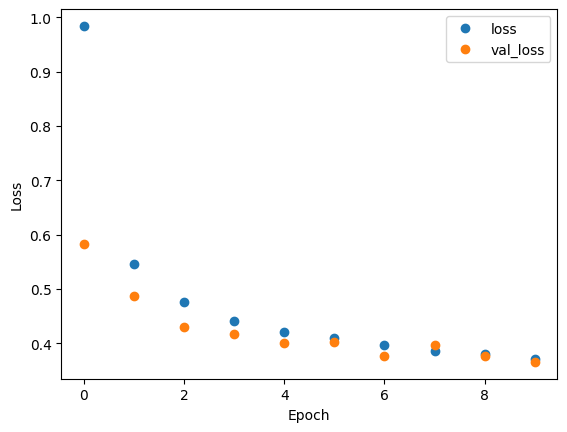

In [14]:
# plot loss
plt.plot(r.history['loss'], 'o', label='loss')
plt.plot(r.history['val_loss'], 'o', label='val_loss',)
plt.ylabel('Loss')  # Set the label for the y-axis
plt.xlabel('Epoch')  # Set the label for the x-axis
plt.legend()
plt.show()

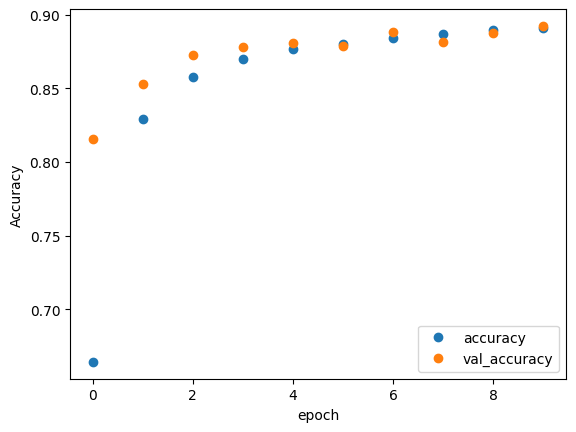

In [15]:
# Plot accuracy
plt.plot(r.history['accuracy'], 'o', label='accuracy')
plt.plot(r.history['val_accuracy'], 'o', label='val_accuracy')
plt.xlabel('epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [16]:
# Evaluate the model with test dataset - evaluate() returns loss and accuracy
print("Training Accuracy: ", model.evaluate(data_train, label_train)[1])
acc_floatingpoint =  model.evaluate(data_test, label_test)[1]
print("Testing Accuracy: ", acc_floatingpoint )

1875/1875 [==============================] - 3s 2ms/step - loss: 0.3614 - accuracy: 0.8934
Training Accuracy:  0.8934166431427002
313/313 [==============================] - 1s 2ms/step - loss: 0.3763 - accuracy: 0.8884
Testing Accuracy:  0.8884000182151794


In [17]:
# save model weights
model.save_weights("weights_FP.weights.h5")

Text(0, 0.5, 'Amount')

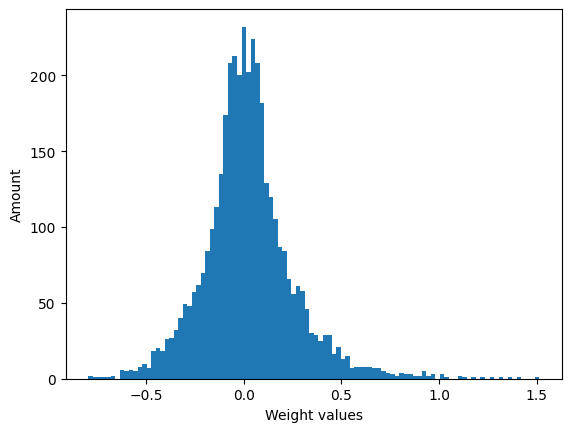

In [18]:
# observe the statistics of weights, for example in the first layer
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Amount')

In [19]:
# What can you observe from the distribution of weights?

# Implement of the trained MLP with numpy

In [20]:
# implement the dense layer
def dense_layer(input_mat, input_vec, bias):
    # input_mat: (out_features, in_features)
    # input_vec: (in_features,)
    # bias: (out_features,)
    return input_mat @ input_vec + bias

In [21]:
# implement the ReLU activation function
def ReLU_layer(in_activations):
    return np.maximum(0, in_activations)

In [22]:
# implement the softmax activation function
def softmax_layer(in_activations):
    # in_activations: (n,)
    in_activations = in_activations - np.max(in_activations)
    exp_z = np.exp(in_activations)
    return exp_z / np.sum(exp_z)

In [23]:
# implement your own MLP, the weighs & biases should be extracted by model.get_weights()
# the softmax layer is not necessary to be implemented
input_example_np = np.ones([28*28])

W1, b1 = model.layers[2].get_weights()
W2, b2 = model.layers[4].get_weights()
W3, b3 = model.layers[6].get_weights()
W4, b4 = model.layers[8].get_weights()

output_1 = ReLU_layer(dense_layer(input_example_np, W1, b1))
output_2 = ReLU_layer(dense_layer(output_1, W2, b2))
output_3 = ReLU_layer(dense_layer(output_2, W3, b3))
output_4 = softmax_layer(dense_layer(output_3, W4, b4))

In [24]:
# Display your own results
output_4

array([6.85728626e-41, 2.56005441e-51, 1.13377419e-23, 1.00000000e+00,
       5.95097540e-85, 1.00233781e-22, 4.00451635e-76, 1.05628707e-48,
       1.88372818e-10, 2.11082812e-40])

In [25]:
# Compare with the reference
model.predict(tf.ones((1, 28, 28)), steps=1)

1/1 [==============================] - 0s 140ms/step


array([[0.0000000e+00, 0.0000000e+00, 1.1337276e-23, 1.0000000e+00,
        0.0000000e+00, 1.0023033e-22, 0.0000000e+00, 0.0000000e+00,
        1.8837010e-10, 0.0000000e+00]], dtype=float32)

# MLP fixed point quantization

In [26]:
# Quantized the weights and evaluate the best combination of Integer and Fractional parts
# Compare the inference acc. with TF model
# Estimate how much memory storage you can save with quantization 

In [27]:
# function to quantize weights with speficied bit width for integer and fractional part
def fixP_quantization(input_weight, int_BW, frac_BW):
    resolution_ = 2**(- frac_BW)
    range_ = 2**(int_BW + 1) # sign bit included
    
    weight = deepcopy(input_weight)
    
    input_weight_clipped = np.clip(weight, - range_ / 2, range_ / 2 - 1)
    input_weight_quantized = np.round(input_weight_clipped/resolution_) * resolution_
    
    return input_weight_quantized        

In [28]:
# weight_quantization
BW_int = 9
BW_frac = 6

In [29]:
weight_quantized = [deepcopy(w) for w in model.get_weights()]

In [30]:
for i in range(len(weight_quantized)):
    weight_quantized[i] = fixP_quantization(np.copy(weight_quantized[i]), BW_int, BW_frac)

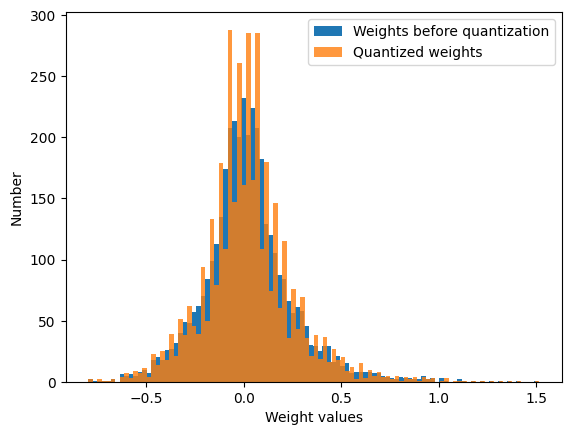

In [31]:
# plot the quantized weights in the first layer as example and compare with the floating point
_ = plt.hist((model.get_weights()[0].flatten()), bins = 100, label = 'Weights before quantization', alpha = 1)
_ = plt.hist((weight_quantized[0].flatten()), bins = 100, label = 'Quantized weights', alpha = 0.8)
plt.xlabel('Weight values')
plt.ylabel('Number')

plt.legend()

In [32]:
# define the quantized model
model_quantized = Model(input_layer, output_layer_act)

In [33]:
# load weights and save 
model_quantized.set_weights(weight_quantized)
model_quantized.save_weights("weights_q_int_{}_frac_{}.weights.h5".format(BW_int, BW_frac))

# Evaluation of the quantization 

In [34]:
model_quantized.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [35]:
# Evaluate the model - evaluate() returns loss and accuracy
print("Train Acc", model_quantized.evaluate(data_train, label_train)[1])
acc_quantized = model_quantized.evaluate(data_test, label_test)[1]
print("Test Acc:", acc_quantized)

1875/1875 [==============================] - 3s 2ms/step - loss: 0.3621 - accuracy: 0.8942
Train Acc 0.8941500186920166
313/313 [==============================] - 1s 2ms/step - loss: 0.3777 - accuracy: 0.8889
Test Acc: 0.8888999819755554


In [36]:
# Summary
# 32 FP numbers utilized in baseline model
saved_memory = 1 / 2
acc_drop = acc_floatingpoint - acc_quantized

In [37]:
print("Saved memory: {}%".format(saved_memory*100))
print("Accuracy drop: {:.2f}%".format(acc_drop*100))

Saved memory: 50.0%
Accuracy drop: -0.05%


# Systematic evaluation

In [38]:
x = np.array([-1.0, -0.75, -0.3, -0.1, 0.1, 0.3, 0.75])

for frac_BW in range(16):
    print(
        frac_BW,
        fixP_quantization(x, int_BW=1, frac_BW=frac_BW)
    )

0 [-1. -1. -0. -0.  0.  0.  1.]
1 [-1.  -1.  -0.5 -0.   0.   0.5  1. ]
2 [-1.   -0.75 -0.25 -0.    0.    0.25  0.75]
3 [-1.    -0.75  -0.25  -0.125  0.125  0.25   0.75 ]
4 [-1.     -0.75   -0.3125 -0.125   0.125   0.3125  0.75  ]
5 [-1.      -0.75    -0.3125  -0.09375  0.09375  0.3125   0.75   ]
6 [-1.       -0.75     -0.296875 -0.09375   0.09375   0.296875  0.75    ]
7 [-1.        -0.75      -0.296875  -0.1015625  0.1015625  0.296875
  0.75     ]
8 [-1.         -0.75       -0.30078125 -0.1015625   0.1015625   0.30078125
  0.75      ]
9 [-1.         -0.75       -0.30078125 -0.09960938  0.09960938  0.30078125
  0.75      ]
10 [-1.         -0.75       -0.29980469 -0.09960938  0.09960938  0.29980469
  0.75      ]
11 [-1.         -0.75       -0.29980469 -0.10009766  0.10009766  0.29980469
  0.75      ]
12 [-1.         -0.75       -0.30004883 -0.10009766  0.10009766  0.30004883
  0.75      ]
13 [-1.         -0.75       -0.30004883 -0.09997559  0.09997559  0.30004883
  0.75      ]
14 [-1.   

In [39]:
# parameter sweep, look for the optimal combination
BW_int = 1
acc_quantized_BW_int_1 = np.zeros(31)
saved_memory_BW_int_1  = np.zeros(31)

for i in range(31):
    BW_frac = i

    weight_quantized = [fixP_quantization(deepcopy(w), BW_int, BW_frac) for w in model.get_weights()] # quantize weights layer by layer

    model_quantized = Model(input_layer, output_layer_act) # define the quantized model
    model_quantized.set_weights(weight_quantized) # set quantized weights
    model_quantized.save_weights("weights_int{}_frac{}.weights.h5".format(BW_int, BW_frac)) # save quantized weights

    model_quantized.compile(optimizer='adam',
                            loss='sparse_categorical_crossentropy',
                            metrics=['accuracy']) # compile model

    # r = model.fit(data_train, label_train, validation_split= 0.2, epochs=10)
    # r.history['accuracy']
    # test_accuracy = model.evaluate(data_test, label_test)[1]

    print("BW_int = {}, BW_frac = {}".format(BW_int, BW_frac))
    acc_quantized_BW_int_1[i] = model_quantized.evaluate(data_test, label_test)[1] # acc evaluation
    saved_memory_BW_int_1[i] = sys.getsizeof(weight_quantized[2:9:2]) / mem_model # save memory evaluation
    print("The saved memory is {}".format(saved_memory_BW_int_1[i]))

BW_int = 1, BW_frac = 0
313/313 [==============================] - 1s 1ms/step - loss: 8.3012 - accuracy: 0.0980
The saved memory is 0.2777777777777778
BW_int = 1, BW_frac = 1
313/313 [==============================] - 1s 1ms/step - loss: 8.3012 - accuracy: 0.0980
The saved memory is 0.2777777777777778
BW_int = 1, BW_frac = 2
313/313 [==============================] - 1s 2ms/step - loss: 8.3012 - accuracy: 0.0980
The saved memory is 0.2777777777777778
BW_int = 1, BW_frac = 3
313/313 [==============================] - 1s 2ms/step - loss: 8.3012 - accuracy: 0.0980
The saved memory is 0.2777777777777778
BW_int = 1, BW_frac = 4
313/313 [==============================] - 1s 2ms/step - loss: 8.3012 - accuracy: 0.0980
The saved memory is 0.2777777777777778
BW_int = 1, BW_frac = 5
313/313 [==============================] - 1s 1ms/step - loss: 8.3012 - accuracy: 0.0980
The saved memory is 0.2777777777777778
BW_int = 1, BW_frac = 6
313/313 [==============================] - 1s 2ms/step - loss: 8

Text(0.5, 1.0, 'BW_int = 1')

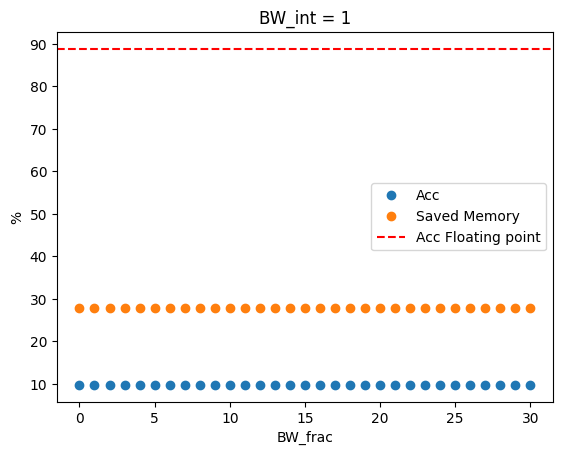

In [40]:
# result visualization
plt.plot(acc_quantized_BW_int_1*100, 'o', label = 'Acc')
plt.plot(saved_memory_BW_int_1*100, 'o', label = 'Saved Memory')
plt.xlabel('BW_frac')
plt.ylabel('%')
plt.axhline(y = acc_floatingpoint*100, color = 'r', linestyle = '--', label = "Acc Floating point")
plt.legend()
plt.title("BW_int = 1")

In [41]:
# parameter sweep
BW_int = 2
acc_quantized_BW_int_2 = np.zeros(30)
saved_memory_BW_int_2  = np.zeros(30)

for i in range(30):
    BW_frac = i

    weight_quantized = [fixP_quantization(deepcopy(w), BW_int, BW_frac) for w in model.get_weights()] # quantize weights layer by layer

    model_quantized = Model(input_layer, output_layer_act) # define the quantized model
    model_quantized.set_weights(weight_quantized) # set quantized weights
    model_quantized.save_weights("weights_int{}_frac{}.weights.h5".format(BW_int, BW_frac)) # save quantized weights

    model_quantized.compile(optimizer='adam',
                            loss='sparse_categorical_crossentropy',
                            metrics=['accuracy']) # compile model

    # r = model.fit(data_train, label_train, validation_split= 0.2, epochs=10)
    # r.history['accuracy']
    # test_accuracy = model.evaluate(data_test, label_test)[1]

    print("BW_int = {}, BW_frac = {}".format(BW_int, BW_frac))
    acc_quantized_BW_int_1[i] = model_quantized.evaluate(data_test, label_test)[1] # acc evaluation
    saved_memory_BW_int_1[i] = sys.getsizeof(weight_quantized[2:9:2]) / mem_model # save memory evaluation
    print("The saved memory is {}".format(saved_memory_BW_int_1[i]))

BW_int = 2, BW_frac = 0
313/313 [==============================] - 1s 2ms/step - loss: 8.3012 - accuracy: 0.0980
The saved memory is 0.2777777777777778
BW_int = 2, BW_frac = 1
313/313 [==============================] - 1s 2ms/step - loss: 8.3012 - accuracy: 0.0980
The saved memory is 0.2777777777777778
BW_int = 2, BW_frac = 2
313/313 [==============================] - 1s 2ms/step - loss: 8.3012 - accuracy: 0.0980
The saved memory is 0.2777777777777778
BW_int = 2, BW_frac = 3
313/313 [==============================] - 1s 2ms/step - loss: 8.3012 - accuracy: 0.0980
The saved memory is 0.2777777777777778
BW_int = 2, BW_frac = 4
313/313 [==============================] - 1s 1ms/step - loss: 8.3012 - accuracy: 0.0980
The saved memory is 0.2777777777777778
BW_int = 2, BW_frac = 5
313/313 [==============================] - 1s 2ms/step - loss: 8.3012 - accuracy: 0.0980
The saved memory is 0.2777777777777778
BW_int = 2, BW_frac = 6
313/313 [==============================] - 1s 2ms/step - loss: 8

Text(0.5, 1.0, 'BW_int = 2')

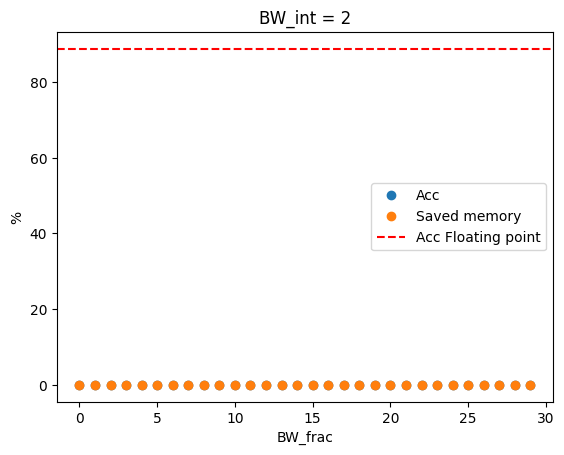

In [42]:
plt.plot(acc_quantized_BW_int_2*100, 'o', label = 'Acc')
plt.plot(saved_memory_BW_int_2*100, 'o', label = 'Saved memory')
plt.axhline(y = acc_floatingpoint*100, color = 'r', linestyle = '--', label = "Acc Floating point")
plt.xlabel('BW_frac')
plt.ylabel('%')
plt.legend()
plt.title("BW_int = 2")

# Pruning

In [43]:
# load lib
# if something goes wrong
# run pip install tensorflow==2.4.1
import tensorflow as tf
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning, prune_low_magnitude

In [44]:
# parameters for training the pruned model
batch_size = 32
epochs = 10
num_images = 60000
 
end_step = np.ceil(num_images / batch_size).astype(np.int32) * epochs

In [45]:
# Define model for pruning.
pruning_params = {
      'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.00,
                                                               final_sparsity=0.80,
                                                               begin_step=3000,
                                                               end_step=end_step)
}

In [55]:
pruned_model = prune_low_magnitude(model, **pruning_params)

In [56]:
# `prune_low_magnitude` requires a recompile.
pruned_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

pruned_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 prune_low_magnitude_flatte  (None, 784)               1         
 n (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 5)                 7847      
 1 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_act_1   (None, 5)                 1         
 (PruneLowMagnitude)                                             
                                                                 
 prune_low_magnitude_dense_  (None, 8)                 90        
 2 (PruneLowMagnitude)                                       

In [57]:
#Keras callback which updates pruning wrappers with the optimizer step. 
#This callback must be used when training a model which needs to be pruned. Not doing so will throw an error.

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),]


history = pruned_model.fit(data_train,
                           label_train,
                           batch_size=batch_size,
                           epochs=epochs, 
                           validation_split = 0.20,
                           callbacks=callbacks)

Epoch 1/10
1500/1500 [==============================] - 9s 3ms/step - loss: 1.1320 - accuracy: 0.6480 - val_loss: 0.5473 - val_accuracy: 0.8500
Epoch 2/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.5274 - accuracy: 0.8519 - val_loss: 0.4790 - val_accuracy: 0.8637
Epoch 3/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.4800 - accuracy: 0.8640 - val_loss: 0.4564 - val_accuracy: 0.8687
Epoch 4/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.4614 - accuracy: 0.8695 - val_loss: 0.4453 - val_accuracy: 0.8712
Epoch 5/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.4670 - accuracy: 0.8663 - val_loss: 0.6479 - val_accuracy: 0.7885
Epoch 6/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.5658 - accuracy: 0.8353 - val_loss: 0.5673 - val_accuracy: 0.8424
Epoch 7/10
1500/1500 [==============================] - 4s 3ms/step - loss: 0.7248 - accuracy: 0.7691 - val_loss: 1.0379 - val_accuracy:

In [58]:
acc_pruned_model = pruned_model.evaluate(data_test, label_test)[1]

313/313 [==============================] - 1s 3ms/step - loss: 1.0342 - accuracy: 0.5965


In [59]:
pruned_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 prune_low_magnitude_flatte  (None, 784)               1         
 n (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 5)                 7847      
 1 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_act_1   (None, 5)                 1         
 (PruneLowMagnitude)                                             
                                                                 
 prune_low_magnitude_dense_  (None, 8)                 90        
 2 (PruneLowMagnitude)                                       

Text(0, 0.5, 'Amount')

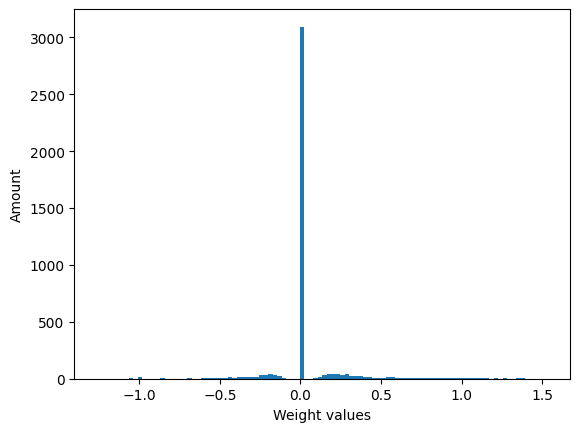

In [60]:
# display the weights in 1st layer of the pruned model
_ = plt.hist((pruned_model.get_weights()[1]).flatten(), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Amount')

Text(0, 0.5, 'Amount')

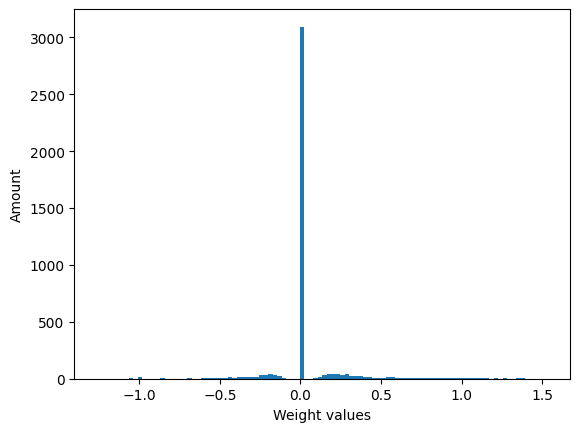

In [61]:
# compare with the original model
_ = plt.hist((model.get_weights()[0]).flatten(), bins = 100)
plt.xlabel('Weight values')
plt.ylabel('Amount')

In [62]:
# calculate the saved memory
# simple assumption: "0" doesn't occupy the space


In [63]:
# compute the saved memory space 
weights_total = __FILL_ME__
get_weights_idx = [3, 9, 15, 21]
for i in range(4):
    weights_pruned += pruned_model.get_weights()[get_weights_idx[i]].sum()

weights_pruned_remained = __FILL_ME__ # remianing weights in the pruned mode

NameError: name '__FILL_ME__' is not defined

In [ ]:
acc_drop_prun =acc_floatingpoint - acc_pruned_model 

In [ ]:
print("The saved memory space by pruning is {:.3f}%".format((1-weights_pruned_remained/weights_total)*100))
print("The accuracy drop is {:.3f}%".format(acc_drop_prun*100))

# Systematic evaluation

In [ ]:
sparisty_vec = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
acc_prun_vec = np.zeros(len(sparisty_vec))

In [ ]:
for i in range(len(sparisty_vec)):
    # Define model for pruning.
    pruning_params = {
      'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.00,
                                                               final_sparsity=__FILL_ME__,
                                                               begin_step=3000,
                                                               end_step=end_step)}
    
    pruned_model = prune_low_magnitude(model, **pruning_params)
    
    pruned_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])
    
    callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),]


    history = pruned_model.fit(data_train,
                           label_train,
                           batch_size=batch_size,
                           epochs=epochs, 
                           validation_split = 0.20,
                           callbacks=callbacks)
    
    acc_prun_vec[i] = pruned_model.evaluate(data_test, label_test)[1]
    

In [ ]:
plt.plot(sparisty_vec, acc_prun_vec*100, 'o', label = 'Pruned Model')
plt.axhline(y = acc_floatingpoint*100, color = 'r', linestyle = '--', label = "Acc Floating point")
plt.xlabel('Saved Memory')
plt.ylabel('%')
plt.legend()